<a href="https://colab.research.google.com/github/yacine-yefsah/Support_Vector_Machine-SVM-/blob/main/Wine_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #722f37; padding: 20px; border-radius: 10px;">
    <h1 style="color: white; text-align: center;"> Classification Multiclasse des Vins</h1>
    <p style="color: #ecf0f1; text-align: center;">Master 1 SAAD - Université de Caen</p>
</div>

### Présentation du Projet
L'objectif est de classer des échantillons de vins provenant de trois cultivateurs différents en fonction de leur composition chimique (Alcool, Magnésium, Proline, etc.). Nous utilisons ici un apprentissage supervisé pour identifier les signatures chimiques propres à chaque vignoble.

##  Analyse Exploratoire des Données (EDA)


In [1]:
from sklearn.datasets import load_wine
import pandas as pd

In [2]:
# Chargement des données
data = load_wine()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [4]:
# Ajout de la cible (le type de vin : 0, 1 ou 2)
df['target'] = data.target

In [13]:
# Vérification du chargement
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
print("--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

--- Valeurs manquantes par colonne ---
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [7]:
print("\n--- Statistiques descriptives ---")
display(df.describe())


--- Statistiques descriptives ---


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [8]:
# Vérification de l'équilibre des classes
print("\n--- Nombre d'échantillons par type de vin (0, 1, 2) ---")
print(df['target'].value_counts())


--- Nombre d'échantillons par type de vin (0, 1, 2) ---
target
1    71
0    59
2    48
Name: count, dtype: int64


**Nous visualisons ici les variables clés pour identifier si les classes (types de vins) sont naturellement séparées par certains composants chimiques.**

/tmp/ipython-input-846618900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='alcohol', data=df, palette='Set2')
/tmp/ipython-input-846618900.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='proline', data=df, palette='Set2')


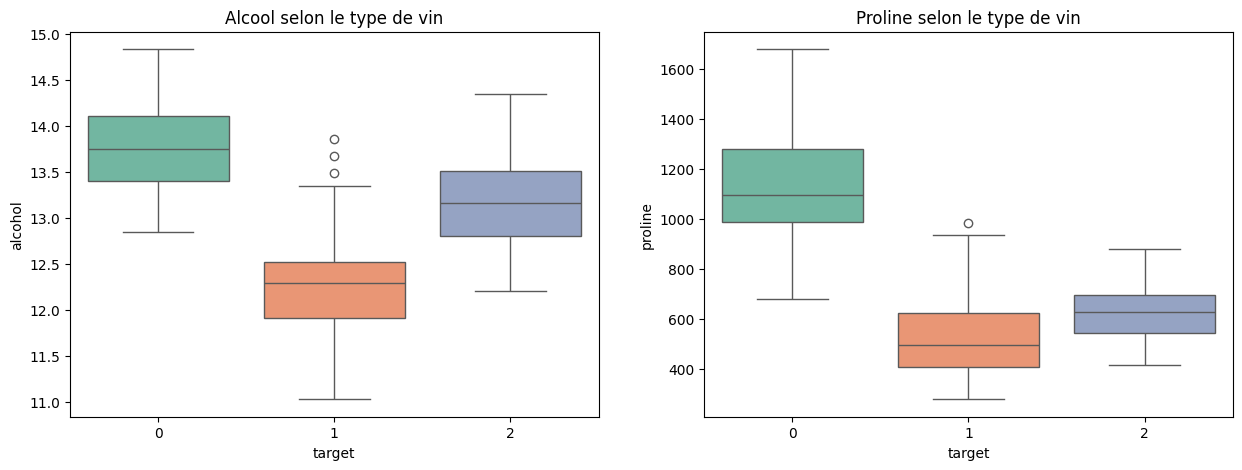

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. Comparaison de l'Alcool par type de vin
plt.subplot(1, 2, 1)
sns.boxplot(x='target', y='alcohol', data=df, palette='Set2')
plt.title('Alcool selon le type de vin')

# 2. Comparaison de la Proline par type de vin
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='proline', data=df, palette='Set2')
plt.title('Proline selon le type de vin')

plt.show()

**On observe que le Vin de Type 0 possède des taux d'alcool et de proline nettement plus élevés que les autres. Le Vin de Type 1 se distingue par les valeurs les plus faibles. Cette séparation claire suggère qu'un modèle linéaire sera très efficace.**

## Preprocessing & Normalisation
Les variables ayant des échelles très différentes (ex: Alcool ~13 vs Proline ~750), nous appliquons une standardisation. Cela garantit que chaque caractéristique contribue équitablement à la décision du modèle.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Séparation des caractéristiques (X) et de la cible (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Séparation en données d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Création du StandardScaler
scaler = StandardScaler()

# 4. On "apprend" l'échelle sur le train et on l'applique sur les deux
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Données découpées et normalisées !")
print(f"Format de X_train_scaled : {X_train_scaled.shape}")

✅ Données découpées et normalisées !
Format de X_train_scaled : (142, 13)


## Modélisation : Support Vector Machine (SVM)
Le SVM est particulièrement robuste pour les petits datasets avec des classes bien définies. Nous utilisons un noyau linéaire pour maximiser la marge entre les groupes.

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.93      0.96        14
           2       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



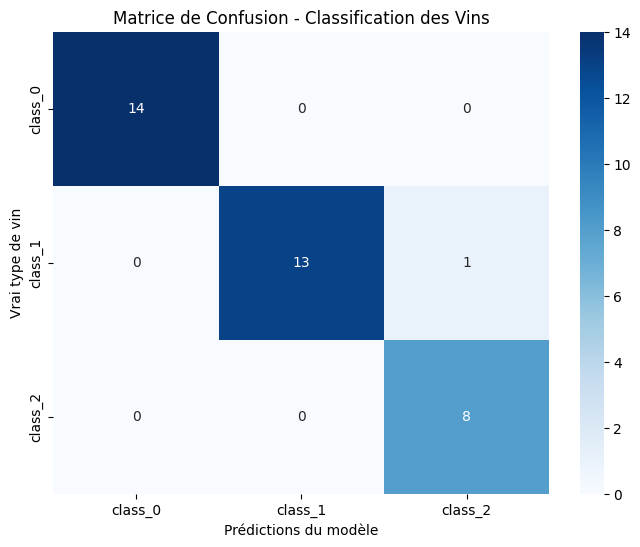

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Création et entraînement du modèle SVM
# On utilise un noyau linéaire car nos boxplots montraient des séparations claires
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_scaled, y_train)

# 2. Prédictions sur les données de test
y_pred = model_svm.predict(X_test_scaled)

# 3. Affichage du rapport de performance
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# 4. Affichage de la Matrice de Confusion
plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Prédictions du modèle')
plt.ylabel('Vrai type de vin')
plt.title('Matrice de Confusion - Classification des Vins')
plt.show()

**Le modèle atteint une Accuracy de 97%. La matrice de confusion montre un seul échantillon mal classé (un vin de type 1 classé en type 2). Les scores de Précision et Rappel proches de 1 prouvent la fiabilité du modèle.**

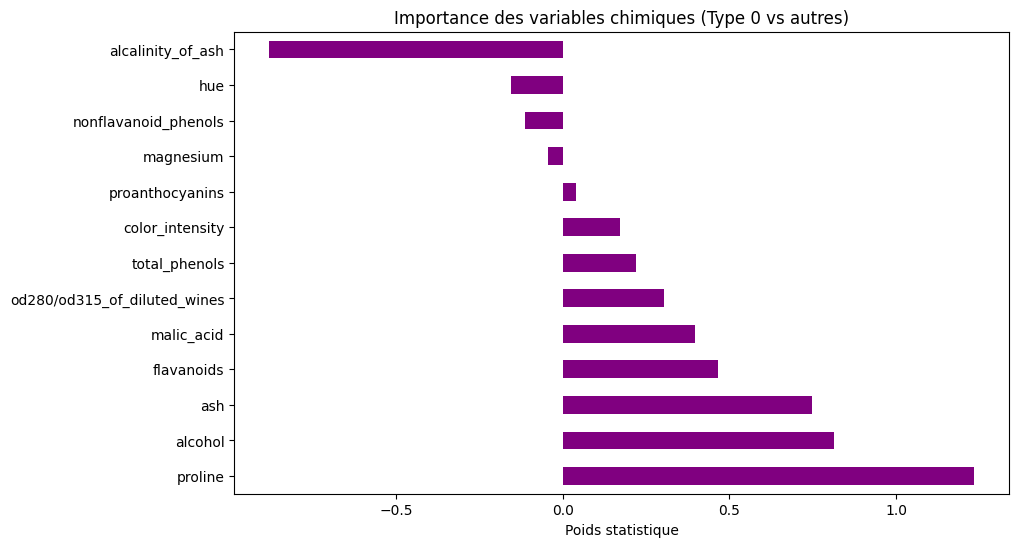

In [12]:
import numpy as np

# 1. Extraction des coefficients pour la première classe (vin de type 0)
# Nous regardons ce qui définit le vin de type 0 par rapport aux autres
coefs = pd.Series(model_svm.coef_[0], index=X.columns)

# 2. On trie par importance
coefs_sorted = coefs.sort_values(ascending=False)

# 3. Visualisation
plt.figure(figsize=(10, 6))
coefs_sorted.plot(kind='barh', color='purple')
plt.title('Importance des variables chimiques (Type 0 vs autres)')
plt.xlabel('Poids statistique')
plt.show()

**Ce projet démontre qu'une analyse chimique précise permet de tracer l'origine d'un vin avec une quasi-certitude. Les variables Proline et Alcool ont été les prédicteurs les plus influents dans cette classification.**